In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


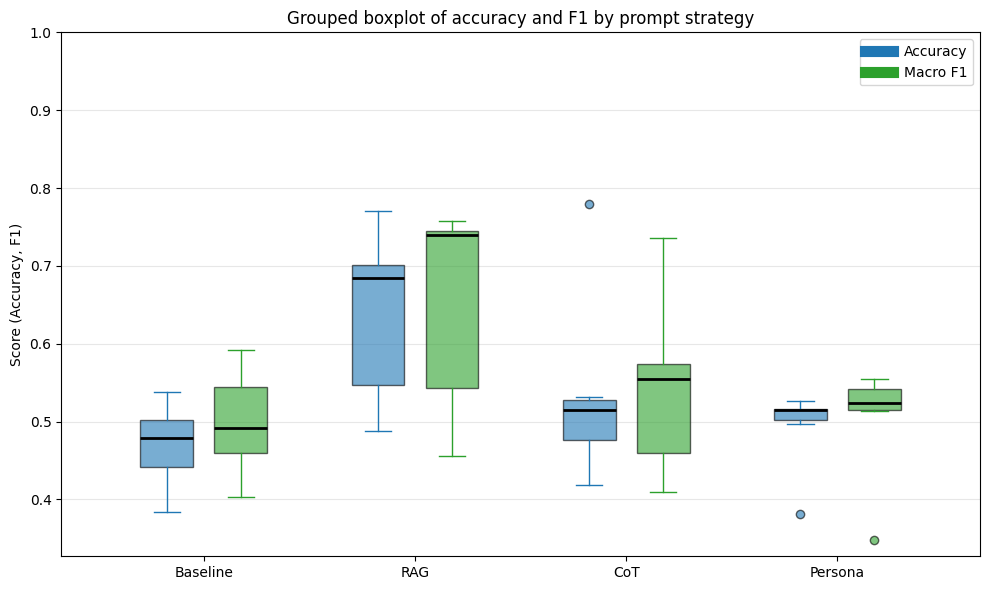

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------
# Data
# ----------------------
A = {
    "Baseline": [0.5134, 0.4122, 0.5383, 0.4717, 0.4792, 0.4911, 0.3841],
    "RAG":     [0.7710,  0.4879, 0.5951, 0.6843, 0.6983, 0.7027, 0.4986],
    "CoT":     [0.7792, 0.5240,  0.5149, 0.4559, 0.5313, 0.4973, 0.4183],
    "Persona": [0.5154, 0.4967, 0.5166, 0.5075, 0.5152, 0.5269, 0.3806]


}

B = {
    "Baseline": [0.5915,	0.4281,	0.5909,	0.4912,	0.4899,	0.4990,	0.4028],
    "RAG":     [0.7426,	0.4561,	0.5803,	0.7397,	0.7573,	0.7459,	0.5053],
    "CoT":     [0.7358,	0.5647,	0.5552,	0.4265,	0.5829,	0.4935,	0.4098],
    "Persona": [0.5545,	0.5241,	0.5355,	0.5473,	0.5154,	0.5134,	0.3484]

}

prompts = list(A.keys())
x = np.arange(len(prompts))
width = 0.35

plt.figure(figsize=(10, 6))

# ----------------------
# A (Blue)
# ----------------------
plt.boxplot(
    [A[p] for p in prompts],
    positions=x - width/2,
    widths=0.25,
    patch_artist=True,
    boxprops=dict(facecolor="tab:blue", alpha=0.6),
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(color="tab:blue"),
    capprops=dict(color="tab:blue"),
    flierprops=dict(markerfacecolor="tab:blue", alpha=0.6),
    showfliers=True
)

# ----------------------
# B (Green)
# ----------------------
plt.boxplot(
    [B[p] for p in prompts],
    positions=x + width/2,
    widths=0.25,
    patch_artist=True,
    boxprops=dict(facecolor="tab:green", alpha=0.6),
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(color="tab:green"),
    capprops=dict(color="tab:green"),
    flierprops=dict(markerfacecolor="tab:green", alpha=0.6),
    showfliers=True
)

# ----------------------
# Axis & legend
# ----------------------
plt.xticks(x, prompts)
plt.ylabel("Score (Accuracy, F1)")
plt.title("Grouped boxplot of accuracy and F1 by prompt strategy")

plt.ylim(top=1.0)


# Custom legend
blue_patch = plt.Line2D([0], [0], color="tab:blue", lw=8, label="Accuracy")
green_patch = plt.Line2D([0], [0], color="tab:green", lw=8, label="Macro F1")
plt.legend(handles=[blue_patch, green_patch])

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
ax.set_yticks(np.arange(0.0, 1.01, 0.1))

/tmp/ipython-input-649748131.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


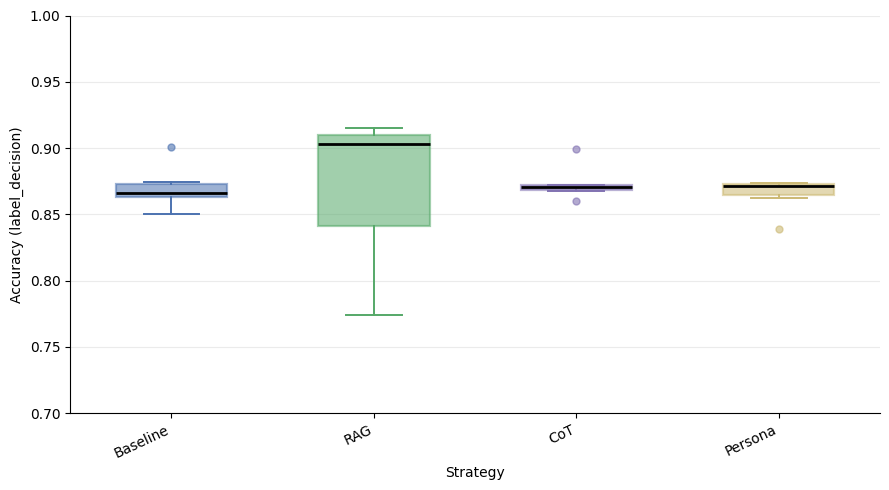

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# ----------------------
# Settings
# ----------------------
CSV_PATH = "/content/drive/MyDrive/MP_KORHateSpeechDetection/Results/Mcnemar/mcnemar_model_fixed_strategy_pairs_uniform.csv"
CRITERION = "label_decision"   # "exact_match" 또는 "label_decision"
OUT_PNG = f"boxplot_strategy_x_{CRITERION}_styled.png"

# x축 전략 순서
strategies = ["Baseline", "RAG", "CoT", "Persona"]

# 원색 느낌 덜한(뮤트 톤) 색상
colors = {
    "Baseline": "#4C72B0",  # muted blue
    "RAG":      "#55A868",  # muted green
    "CoT":      "#8172B2",  # muted purple
    "Persona":  "#CCB974",  # muted yellow
}

# ----------------------
# 1) Read & build (model, strategy) accuracy table (24 values)
# ----------------------
df = pd.read_csv(CSV_PATH)
df = df[df["criterion"] == CRITERION].copy()

left = df[["model_a", "strategy_a", "accuracy_a"]].rename(
    columns={"model_a":"model", "strategy_a":"strategy", "accuracy_a":"accuracy"}
)
right = df[["model_a", "strategy_b", "accuracy_b"]].rename(
    columns={"model_a":"model", "strategy_b":"strategy", "accuracy_b":"accuracy"}
)

acc = pd.concat([left, right], ignore_index=True)
acc = acc.drop_duplicates(["model", "strategy"], keep="first")

# 전략별(모델 6개) 값 리스트
data = [acc.loc[acc["strategy"] == s, "accuracy"].tolist() for s in strategies]

# ----------------------
# 2) Boxplot with fully matched line colors
# ----------------------
fig, ax = plt.subplots(figsize=(9, 5))

bp = ax.boxplot(
    data,
    labels=strategies,
    widths=0.55,
    patch_artist=True,
    showfliers=True,
    medianprops=dict(color="black", linewidth=2),
)

# 각 전략 박스에 대해 선/점/테두리 색을 동일하게 맞춤
for i, s in enumerate(strategies):
    c = colors[s]

    # box (채움 + 테두리)
    bp["boxes"][i].set_facecolor(c)
    bp["boxes"][i].set_alpha(0.55)
    bp["boxes"][i].set_edgecolor(c)
    bp["boxes"][i].set_linewidth(1.6)

    # whiskers: 2개씩
    bp["whiskers"][2*i].set_color(c)
    bp["whiskers"][2*i+1].set_color(c)
    bp["whiskers"][2*i].set_linewidth(1.4)
    bp["whiskers"][2*i+1].set_linewidth(1.4)

    # caps: 2개씩
    bp["caps"][2*i].set_color(c)
    bp["caps"][2*i+1].set_color(c)
    bp["caps"][2*i].set_linewidth(1.4)
    bp["caps"][2*i+1].set_linewidth(1.4)

    # fliers: 1개(보통)
    if len(bp["fliers"]) > i:
        bp["fliers"][i].set_marker("o")
        bp["fliers"][i].set_markerfacecolor(c)
        bp["fliers"][i].set_markeredgecolor(c)
        bp["fliers"][i].set_alpha(0.6)
        bp["fliers"][i].set_markersize(5)

# ----------------------
# 3) Clean axes (예시처럼 깔끔하게)
# ----------------------
# ----------------------
# 4) Axes (제목 없음, y축 강제 확대)
# ----------------------
ax.set_title("")
ax.set_xlabel("Strategy")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
ax.set_ylabel(f"Accuracy ({CRITERION})")

ax.set_ylim(0.70, 1.0)  # 브라켓 공간 더 필요하면 1.10 - label decision
#ax.set_ylim(0, 1.0)

ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


/tmp/ipython-input-1543349299.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


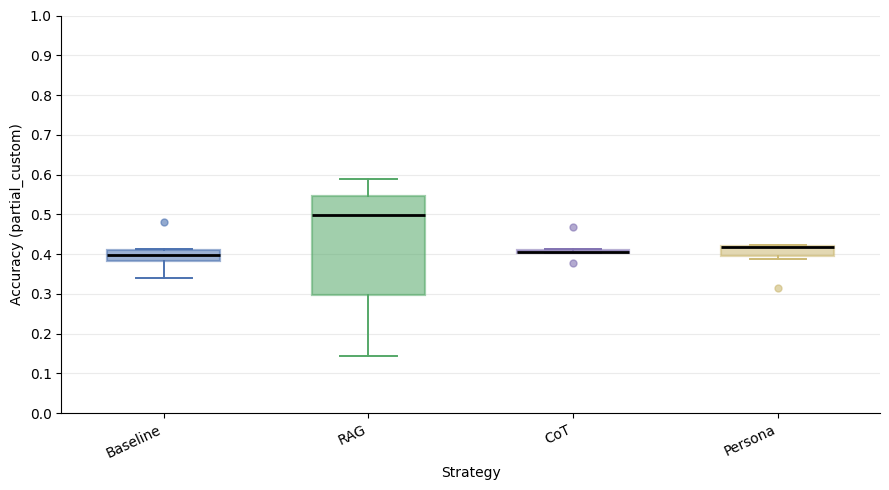

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------
# Settings
# ----------------------
CSV_PATH = "/content/drive/MyDrive/MP_KORHateSpeechDetection/Results/Mcnemar/mcnemar_model_fixed_strategy_pairs_partial_custom.csv"
CRITERION = "partial_custom"   # "exact_match" 또는 "label_decision"
OUT_PNG = f"boxplot_strategy_x_{CRITERION}_styled.png"

# x축 전략 순서
strategies = ["Baseline", "RAG", "CoT", "Persona"]

# 원색 느낌 덜한(뮤트 톤) 색상
colors = {
    "Baseline": "#4C72B0",  # muted blue
    "RAG":      "#55A868",  # muted green
    "CoT":      "#8172B2",  # muted purple
    "Persona":  "#CCB974",  # muted yellow
}

# ----------------------
# 1) Read & build (model, strategy) accuracy table (24 values)
# ----------------------
df = pd.read_csv(CSV_PATH)
df = df[df["criterion"] == CRITERION].copy()

left = df[["model_a", "strategy_a", "accuracy_a"]].rename(
    columns={"model_a":"model", "strategy_a":"strategy", "accuracy_a":"accuracy"}
)
right = df[["model_a", "strategy_b", "accuracy_b"]].rename(
    columns={"model_a":"model", "strategy_b":"strategy", "accuracy_b":"accuracy"}
)

acc = pd.concat([left, right], ignore_index=True)
acc = acc.drop_duplicates(["model", "strategy"], keep="first")

# 전략별(모델 6개) 값 리스트
data = [acc.loc[acc["strategy"] == s, "accuracy"].tolist() for s in strategies]

# ----------------------
# 2) Boxplot with fully matched line colors
# ----------------------
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_yticks(np.arange(0.0, 1.01, 0.1))
bp = ax.boxplot(
    data,
    labels=strategies,
    widths=0.55,
    patch_artist=True,
    showfliers=True,
    medianprops=dict(color="black", linewidth=2),
)

# 각 전략 박스에 대해 선/점/테두리 색을 동일하게 맞춤
for i, s in enumerate(strategies):
    c = colors[s]

    # box (채움 + 테두리)
    bp["boxes"][i].set_facecolor(c)
    bp["boxes"][i].set_alpha(0.55)
    bp["boxes"][i].set_edgecolor(c)
    bp["boxes"][i].set_linewidth(1.6)

    # whiskers: 2개씩
    bp["whiskers"][2*i].set_color(c)
    bp["whiskers"][2*i+1].set_color(c)
    bp["whiskers"][2*i].set_linewidth(1.4)
    bp["whiskers"][2*i+1].set_linewidth(1.4)

    # caps: 2개씩
    bp["caps"][2*i].set_color(c)
    bp["caps"][2*i+1].set_color(c)
    bp["caps"][2*i].set_linewidth(1.4)
    bp["caps"][2*i+1].set_linewidth(1.4)

    # fliers: 1개(보통)
    if len(bp["fliers"]) > i:
        bp["fliers"][i].set_marker("o")
        bp["fliers"][i].set_markerfacecolor(c)
        bp["fliers"][i].set_markeredgecolor(c)
        bp["fliers"][i].set_alpha(0.6)
        bp["fliers"][i].set_markersize(5)

# ----------------------
# 3) Clean axes (예시처럼 깔끔하게)
# ----------------------
# ----------------------
# 4) Axes (제목 없음, y축 강제 확대)
# ----------------------
ax.set_title("")
ax.set_xlabel("Strategy")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
ax.set_ylabel(f"Accuracy ({CRITERION})")

#ax.set_ylim(0.70, 1.00)  # 브라켓 공간 더 필요하면 1.10 - label decision
ax.set_ylim(0, 1.0)

ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


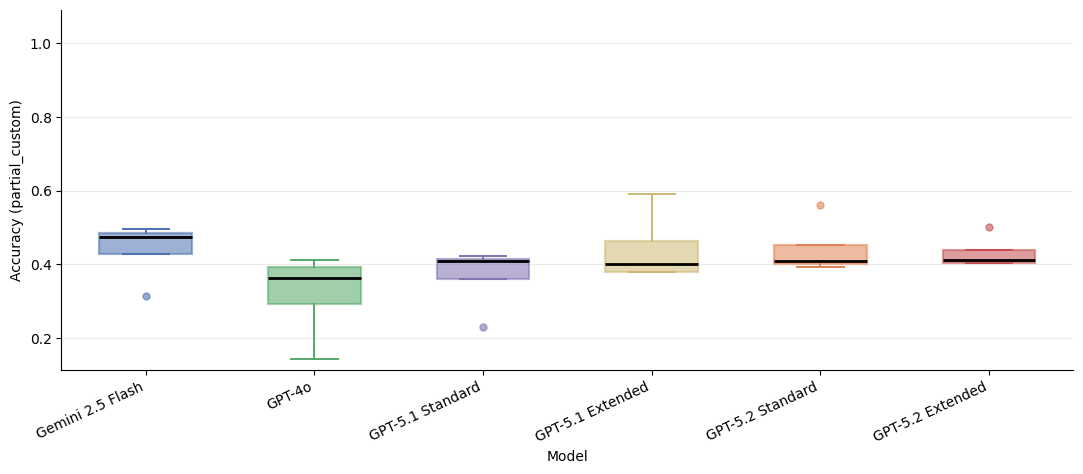

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------
# Settings
# ----------------------
CSV_PATH = "/content/drive/MyDrive/MP_KORHateSpeechDetection/Results/Mcnemar/mcnemar_strategy_fixed_model_pairs_partial_custom.csv"
CRITERION = "partial_custom"   # "exact_match" 또는 "label_decision"

# 박스 안에 들어갈 전략 4개 값의 순서
strategies = ["Baseline", "RAG", "CoT", "Persona"]

# ✅ CSV의 모델 키(6개) -> 원하는 표기명
model_key_to_pretty = {
    "gemini2.5-flash": "Gemini 2.5 Flash",
    "gpt4o":           "GPT-4o",
    "gpt5.1st":        "GPT-5.1 Standard",
    "gpt5.1et":        "GPT-5.1 Extended",
    "gpt5.2st":        "GPT-5.2 Standard",
    "gpt5.2et":        "GPT-5.2 Extended",
}

# ✅ x축 모델 순서(원하신 순서)
model_order_keys = ["gemini2.5-flash", "gpt4o", "gpt5.1st", "gpt5.1et", "gpt5.2st", "gpt5.2et"]
model_order = [model_key_to_pretty[k] for k in model_order_keys]

# ✅ 모델 6개 뮤트톤
model_colors = {
    "Gemini 2.5 Flash":          "#4C72B0",
    "GPT-4o":                    "#55A868",
    "GPT-5.1 Standard": "#8172B2",
    "GPT-5.1 Extended": "#CCB974",
    "GPT-5.2 Standard": "#DD8452",
    "GPT-5.2 Extended": "#C44E52",
}

# ----------------------
# 1) Read (중요: 이 파일은 strategy 컬럼이 없고 strategy_a/strategy_b임)
# ----------------------
df = pd.read_csv(CSV_PATH)
df = df[df["criterion"] == CRITERION].copy()

# ✅ 전략 고정 파일이므로 strategy_a == strategy_b → strategy 하나로 통일
df["strategy"] = df["strategy_a"]

# (선택) 혹시라도 다른 값이 섞였는지 확인하고 싶으면 주석 해제
# if (df["strategy_a"] != df["strategy_b"]).any():
#     raise ValueError("strategy_a and strategy_b are not identical in some rows.")

left  = df[["strategy", "model_a", "accuracy_a"]].rename(columns={"model_a":"model", "accuracy_a":"accuracy"})
right = df[["strategy", "model_b", "accuracy_b"]].rename(columns={"model_b":"model", "accuracy_b":"accuracy"})

acc = pd.concat([left, right], ignore_index=True)

# 모델 키 -> 표기명으로 변경
acc["model_pretty"] = acc["model"].map(model_key_to_pretty)

# 매핑 안 된 모델이 있으면 바로 잡기
if acc["model_pretty"].isna().any():
    unmapped = sorted(acc.loc[acc["model_pretty"].isna(), "model"].unique())
    raise ValueError(f"Unmapped model keys in CSV: {unmapped}")

# (model, strategy) 하나만 남기기
acc = acc.drop_duplicates(["model_pretty", "strategy"], keep="first")

# ----------------------
# 2) x축=모델, 박스 안 값=전략 4개
# ----------------------
data = []
for m_pretty in model_order:
    sub = acc[acc["model_pretty"] == m_pretty].set_index("strategy").reindex(strategies)
    vals = sub["accuracy"].tolist()
    if any(pd.isna(v) for v in vals):
        raise ValueError(f"Missing accuracy for model={m_pretty}. (Some strategies not found in CSV)")
    data.append(vals)

# ----------------------
# 3) Boxplot
# ----------------------
fig, ax = plt.subplots(figsize=(11, 5))

bp = ax.boxplot(
    data,
    tick_labels=model_order,
    widths=0.55,
    patch_artist=True,
    showfliers=True,
    medianprops=dict(color="black", linewidth=2),
)

for i, m_pretty in enumerate(model_order):
    c = model_colors[m_pretty]

    bp["boxes"][i].set_facecolor(c)
    bp["boxes"][i].set_alpha(0.55)
    bp["boxes"][i].set_edgecolor(c)
    bp["boxes"][i].set_linewidth(1.6)

    bp["whiskers"][2*i].set_color(c)
    bp["whiskers"][2*i+1].set_color(c)
    bp["whiskers"][2*i].set_linewidth(1.4)
    bp["whiskers"][2*i+1].set_linewidth(1.4)

    bp["caps"][2*i].set_color(c)
    bp["caps"][2*i+1].set_color(c)
    bp["caps"][2*i].set_linewidth(1.4)
    bp["caps"][2*i+1].set_linewidth(1.4)

    if len(bp["fliers"]) > i:
        bp["fliers"][i].set_marker("o")
        bp["fliers"][i].set_markerfacecolor(c)
        bp["fliers"][i].set_markeredgecolor(c)
        bp["fliers"][i].set_alpha(0.6)
        bp["fliers"][i].set_markersize(5)

# ----------------------
# 4) Axes (제목 없음, y축 강제 확대)
# ----------------------
ax.set_title("")
ax.set_xlabel("Model")
plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
ax.set_ylabel(f"Accuracy ({CRITERION})")

#ax.set_ylim(0, 1.0)  # 브라켓 공간 더 필요하면 1.10 - label decision
#ax.set_ylim(0, 1.0)

all_vals = [v for sub in data for v in sub]
ymin, ymax = min(all_vals), max(all_vals)

pad_bottom = 0.03
pad_top    = 0.50   # 브라켓 올릴 공간이면 여기만 좀 넉넉히
ax.set_ylim(ymin - pad_bottom, ymax + pad_top)

ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

#plt.tight_layout()
fig.subplots_adjust(left=0.07, right=0.99, top=0.95, bottom=0.23)
plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
plt.show()
